In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('lifesat.csv')

In [3]:
# Q1 (5 marks) Load the dataset lifesat.csv and display the first 5 rows.
data.head(5)

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [4]:
# Q2 (5 marks) Print basic info and summary statistics .
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     object 
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), object(1)
memory usage: 780.0+ bytes


In [5]:
data.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


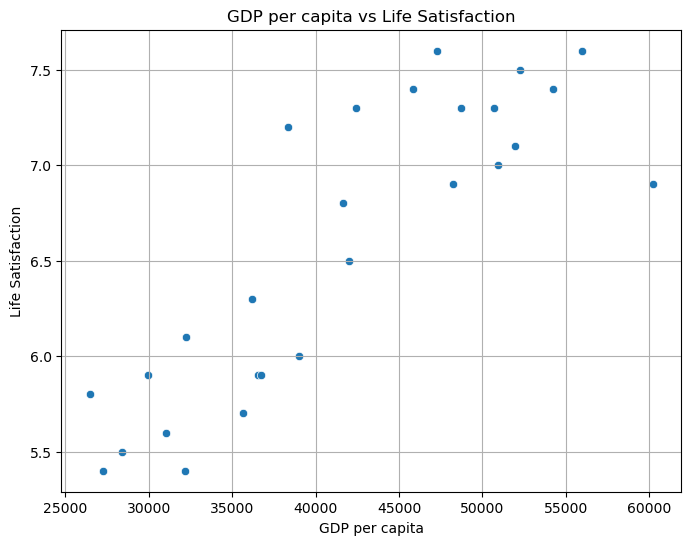

In [6]:
# Q3 (10 marks) Display a scatter plot for GDP per capita vs Life Satisfaction . Add labels, title, and discuss the observed relationship
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x = 'GDP per capita (USD)', y = 'Life satisfaction')
plt.xlabel('GDP per capita')
plt.ylabel('Life Satisfaction')
plt.title('GDP per capita vs Life Satisfaction')
plt.grid(True)
plt.show()

## Discuss the observed relationship:
In the plot, we can see that GDP per capita is an important factor influencing life satisfaction. However, GDP alone is not enough to fully explain life satisfaction, because in some countries other factors, such as culture, healthcare, and social support, can play a more significant role.

In [7]:
# Q4 (5 marks) Extract input (X) and target (y). Print their shape
X = data[['GDP per capita (USD)']] # [[]] -> DataFrame
y = data['Life satisfaction']    

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (27, 1)
Shape of y: (27,)


In [8]:
# Q5 (10 marks) Train a Linear Regression model & Display coefficient and intercept
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (slope): 6.778899694341222e-05
Intercept: 3.7490494273769093


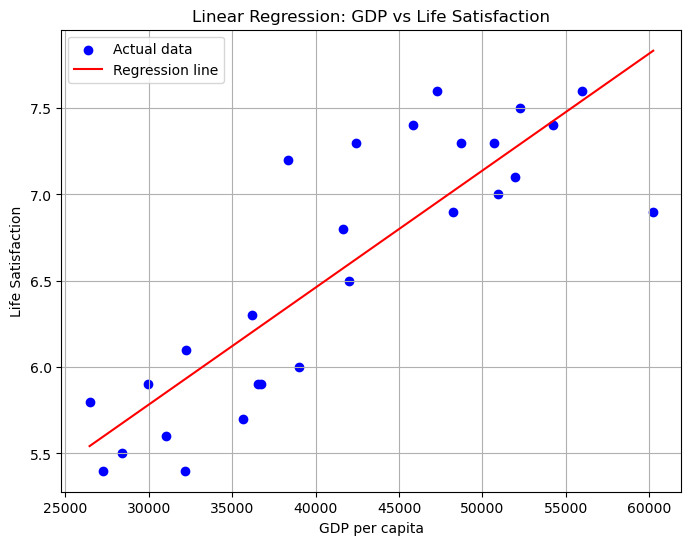

In [9]:
# Q6 (10 marks) Plot the predicted regression line from the model along with a scatter plot of the data.

y_pred = model.predict(X)  # prediction 

plt.figure(figsize=(8,6))
plt.scatter(X, y, label='Actual data', color='blue')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel('GDP per capita')
plt.ylabel('Life Satisfaction')
plt.title('Linear Regression: GDP vs Life Satisfaction')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Q7 (5 marks) Predict Life Satisfaction for GDP = 37,655.2 USD. Comment on result.
gdp = 37655.2
life_satisfaction_pred = model.predict([[gdp]])
print("Predicted Life Satisfaction for GDP = 37,655.2 USD:", life_satisfaction_pred[0])

Predicted Life Satisfaction for GDP = 37,655.2 USD: 6.301657665080485


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
# Q8 (5 marks) Train a KNeighborsRegressor (n_neighbors=3).
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
# Q9 (10 marks) Predict Life Satisfaction for GDP = 37,655.2 USD and compare with Linear Regression.
gdp_value = 37655.2
life_satisfaction_knn = knn_model.predict([[gdp_value]])
print("Predicted Life Satisfaction (KNN) for GDP = 37,655.2 USD:", life_satisfaction_knn[0])

print()

life_satisfaction_lr = model.predict(pd.DataFrame({'GDP per capita (USD)': [gdp_value]}))
print("Predicted Life Satisfaction (Linear Regression) for GDP = 37,655.2 USD:", life_satisfaction_lr[0])

Predicted Life Satisfaction (KNN) for GDP = 37,655.2 USD: 6.333333333333333

Predicted Life Satisfaction (Linear Regression) for GDP = 37,655.2 USD: 6.301657665080485


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


Predicted Life Satisfaction (KNN, n_neighbors=1) = 7.20
Predicted Life Satisfaction (KNN, n_neighbors=3) = 6.33
Predicted Life Satisfaction (KNN, n_neighbors=5) = 6.26
Predicted Life Satisfaction (KNN, n_neighbors=10) = 6.37


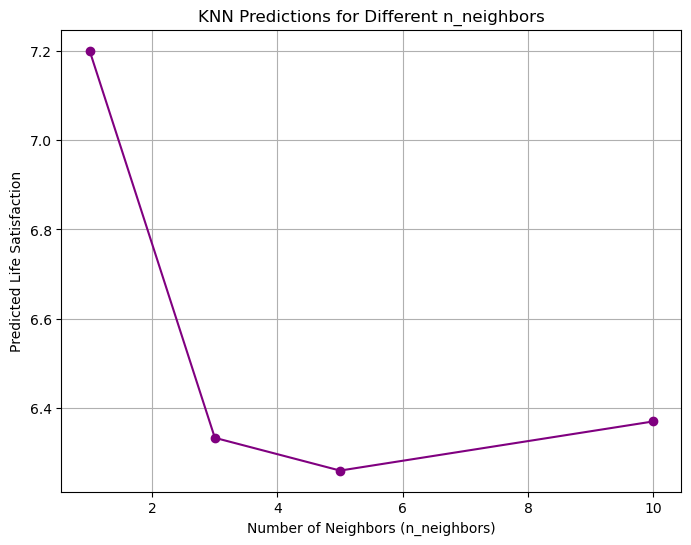

In [13]:
# Q10 (10 marks)
# Use n_neighbors 1, 3, 5, and 10 and print the predicted values of life satisfaction in Q10.
# Plot the results using a line plot.
gdp_value = 37655.2
neighbors_list = [1, 3, 5, 10]
predictions = {}

for k in neighbors_list:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X, y)
    pred = knn.predict([[gdp_value]])[0]
    predictions[k] = pred
    print(f"Predicted Life Satisfaction (KNN, n_neighbors={k}) = {pred:.2f}")


plt.figure(figsize=(8,6))
plt.plot(list(predictions.keys()), list(predictions.values()), marker='o', linestyle='-', color='purple')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Predicted Life Satisfaction')
plt.title('KNN Predictions for Different n_neighbors')
plt.grid(True)
plt.show()

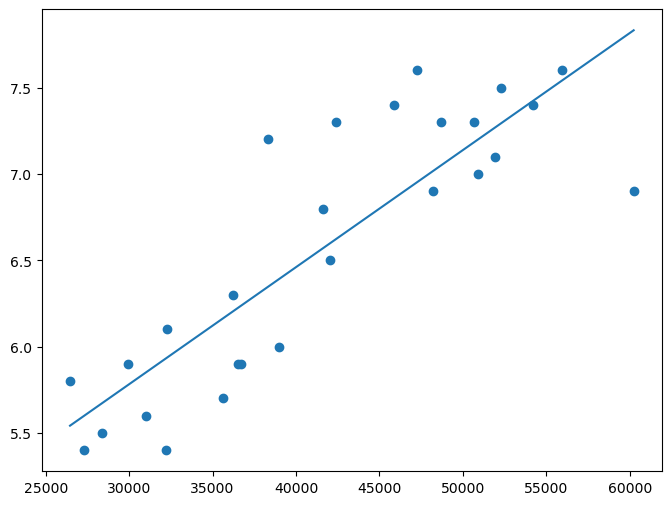

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(X, y_pred, label='Prediction Data')
plt.scatter(X, y, label='Actual Data')
plt.show()

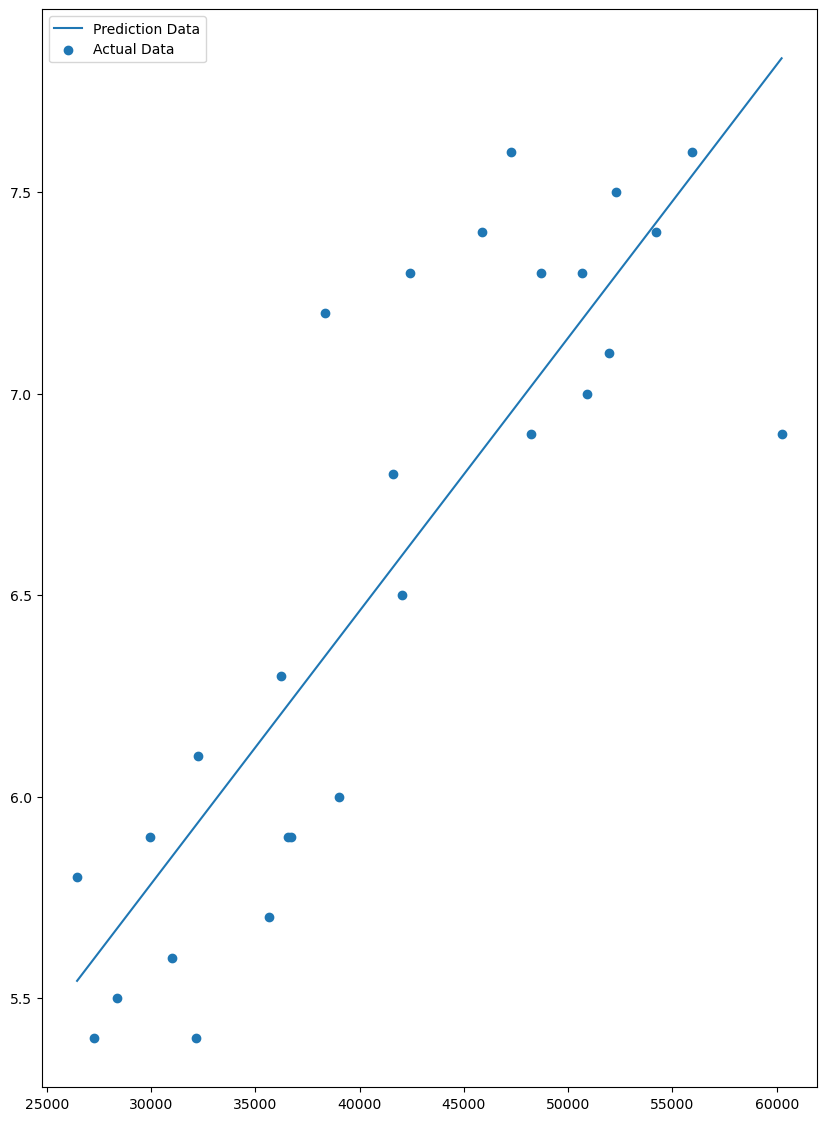

In [23]:
plt.figure(figsize=(10,14))
plt.plot(X, y_pred, label="Prediction Data")
plt.scatter(X, y, label="Actual Data")
plt.legend()